# Homework 3: NYC Taxi Analytics

## Part 2: Start Spark

In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("NYC Taxi Analytics Assignment")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/24 02:57:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Part 3: Load yellow and green taxi data

In [2]:
yellow_df = spark.read.parquet("data/yellow_tripdata_2026-01.parquet")
green_df = spark.read.parquet("data/green_tripdata_2026-01.parquet")

print("Yellow Taxi Dataframe Schema:")
yellow_df.printSchema()

print("\n\nGreen Taxi Dataframe Schema:")
green_df.printSchema()

Yellow Taxi Dataframe Schema:
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



Green Taxi Dataframe Schema:
root
 |-- Vend

In [3]:
print("Yellow Taxi Dataframe:")
yellow_df.show(5, truncate=False)

print("\n\nGreen Taxi Dataframe:")
green_df.show(5, truncate=False)

Yellow Taxi Dataframe:


+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|2       |2026-01-01 00:54:04 |2026-01-01 00:59:37  |1              |0.97         |1         |N                 |239         |238 

## Part 4: Standardize schemas

In [4]:
from pyspark.sql.functions import col

# yellow taxi
yellow = yellow_df.select(
    col("tpep_pickup_datetime").alias("pickup_time"),
    col("tpep_dropoff_datetime").alias("dropoff_time"),
    col("PULocationID").alias("pickup_loc"),
    col("DOLocationID").alias("dropoff_loc"),
    col("trip_distance"),
    col("fare_amount"),
    col("total_amount")
)
yellow.show(5, truncate=False)

+-------------------+-------------------+----------+-----------+-------------+-----------+------------+
|pickup_time        |dropoff_time       |pickup_loc|dropoff_loc|trip_distance|fare_amount|total_amount|
+-------------------+-------------------+----------+-----------+-------------+-----------+------------+
|2026-01-01 00:54:04|2026-01-01 00:59:37|239       |238        |0.97         |7.2        |15.86       |
|2026-01-01 00:34:04|2026-01-01 00:39:47|163       |162        |0.9          |7.9        |13.65       |
|2026-01-01 00:57:06|2026-01-01 01:05:59|43        |237        |1.4          |10.7       |18.95       |
|2026-01-01 00:15:22|2026-01-01 00:58:10|142       |209        |5.58         |38.7       |55.56       |
|2026-01-01 00:27:13|2026-01-01 00:40:43|88        |144        |2.16         |13.5       |23.1        |
+-------------------+-------------------+----------+-----------+-------------+-----------+------------+
only showing top 5 rows


In [5]:
green = green_df.select(
    col("lpep_pickup_datetime").alias("pickup_time"),
    col("lpep_dropoff_datetime").alias("dropoff_time"),
    col("PULocationID").alias("pickup_loc"),
    col("DOLocationID").alias("dropoff_loc"),
    col("trip_distance"),
    col("fare_amount"),
    col("total_amount")
)
green.show(5, truncate=False)

+-------------------+-------------------+----------+-----------+-------------+-----------+------------+
|pickup_time        |dropoff_time       |pickup_loc|dropoff_loc|trip_distance|fare_amount|total_amount|
+-------------------+-------------------+----------+-----------+-------------+-----------+------------+
|2026-01-01 00:27:58|2026-01-01 00:55:16|65        |233        |6.2          |31.7       |45.2        |
|2026-01-01 00:44:33|2026-01-01 01:32:56|66        |188        |5.36         |50.0       |61.2        |
|2026-01-01 00:23:45|2026-01-01 00:45:03|65        |179        |10.6         |41.5       |46.0        |
|2026-01-01 00:44:33|2026-01-01 01:00:45|42        |141        |4.2          |19.8       |25.05       |
|2026-01-01 00:46:04|2026-01-01 01:04:40|95        |82         |2.76         |19.1       |21.6        |
+-------------------+-------------------+----------+-----------+-------------+-----------+------------+
only showing top 5 rows


In [6]:
# add taxi type
from pyspark.sql.functions import lit

green = green.withColumn("taxi_type", lit("green"))
yellow = yellow.withColumn("taxi_type", lit("yellow"))

In [7]:
# combine
df = yellow.unionByName(green)
df.printSchema()

root
 |-- pickup_time: timestamp_ntz (nullable = true)
 |-- dropoff_time: timestamp_ntz (nullable = true)
 |-- pickup_loc: integer (nullable = true)
 |-- dropoff_loc: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- taxi_type: string (nullable = false)



## Part 5: Clean the data

In [8]:
from pyspark.sql.functions import unix_timestamp

# remove rows with missing pickup/drop-off timestamps
clean_df = (df.dropna(subset=["pickup_time", "dropoff_time"])
    # remove trips with non-positive distance
    .filter(col("trip_distance") > 0)
    # with negative fares
    .filter(col("fare_amount") >= 0)
    # with negative total amount
    .filter(col("total_amount") >= 0)
    # longer than 24 hours (86400 seconds)
    .filter((unix_timestamp("dropoff_time") - unix_timestamp("pickup_time")) <= 86400)
    # with drop-off time before pickup time
    .filter(col("dropoff_time") > col("pickup_time"))
)

print("Before Cleanup:")
print(f"{df.count()} rows")

print("\n\nAfter Cleanup:")
print(f"{clean_df.count()} rows")

Before Cleanup:
3765161 rows


After Cleanup:


[Stage 9:>                                                          (0 + 2) / 3]

3557037 rows


## Part 6: Required analytics

### 1. Which taxi type had more trips?

In [9]:
trips_by_type = (clean_df.groupBy("taxi_type")
                 .count())
trips_by_type.show()

[Stage 12:===================>                                      (1 + 2) / 3]

+---------+-------+
|taxi_type|  count|
+---------+-------+
|   yellow|3518128|
|    green|  38909|
+---------+-------+



### 2. What was the average fare by taxi type?

In [10]:
from pyspark.sql.functions import avg

avg_fare_by_type = (clean_df.groupBy("taxi_type")
                    .agg(avg("fare_amount").alias("avg_fare")))
avg_fare_by_type.show()

[Stage 15:======================================>                   (2 + 1) / 3]

+---------+------------------+
|taxi_type|          avg_fare|
+---------+------------------+
|   yellow| 21.08260282173478|
|    green|16.003356806908457|
+---------+------------------+



### 3. What was the average trip distance by taxi type?

In [11]:
avg_fare_by_type = (clean_df.groupBy("taxi_type")
                    .agg(avg("trip_distance").alias("avg_distance")))
avg_fare_by_type.show()

[Stage 18:===================>                                      (1 + 2) / 3]

+---------+-----------------+
|taxi_type|     avg_distance|
+---------+-----------------+
|   yellow|6.757001624157525|
|    green|12.98990593435966|
+---------+-----------------+



### 5. What percentage of trips were under 2 miles?

In [12]:
total = clean_df.count()

short_trips = (clean_df.filter(col("trip_distance") < 2)
               .count())

percentage = (short_trips / total) * 100

print("Percentage under 2 miles:", percentage)

[Stage 24:======================================>                   (2 + 1) / 3]

Percentage under 2 miles: 51.95206009945919


### 8. Predict the fare amount using non-fare predictor columns

In [13]:
# transform timestamp
from pyspark.sql.functions import hour, dayofweek

df_features = (clean_df
    .withColumn("pickup_hour", hour("pickup_time"))
    .withColumn("pickup_dayofweek", dayofweek("pickup_time"))
    .withColumn(
        "trip_duration",
        unix_timestamp("dropoff_time") - unix_timestamp("pickup_time")
    ))

In [14]:
# transform string
from pyspark.ml.feature import OneHotEncoder, StringIndexer

indexer = StringIndexer(
    inputCol="taxi_type",
    outputCol="taxi_type_index"
)

df_features = indexer.fit(df_features).transform(df_features)

encoder = OneHotEncoder(
    inputCol="taxi_type_index",
    outputCol="taxi_type_vec"
)

df_features = encoder.fit(df_features).transform(df_features)

In [15]:
# select feature
feature_cols = [
    "trip_distance",
    "pickup_hour",
    "pickup_dayofweek",
    "trip_duration",
    "pickup_loc",
    "dropoff_loc",
    "taxi_type_vec"
]

In [16]:
# assemble
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

ml_df = assembler.transform(df_features).select("features", "fare_amount")

In [17]:
# train test split
train, test = ml_df.randomSplit([0.8, 0.2])

In [18]:
# train
from pyspark.ml.regression import GBTRegressor

gbt = GBTRegressor(featuresCol="features", labelCol="fare_amount", maxDepth=12, seed=42)
model = gbt.fit(train)

26/05/24 02:59:04 WARN DAGScheduler: Broadcasting large task binary with size 1048.0 KiB
26/05/24 02:59:05 WARN DAGScheduler: Broadcasting large task binary with size 1026.1 KiB
26/05/24 02:59:06 WARN MemoryStore: Not enough space to cache rdd_232_0 in memory! (computed 65.8 MiB so far)
26/05/24 02:59:06 WARN BlockManager: Persisting block rdd_232_0 to disk instead.
26/05/24 02:59:07 WARN MemoryStore: Not enough space to cache rdd_232_1 in memory! (computed 19.5 MiB so far)
26/05/24 02:59:07 WARN BlockManager: Persisting block rdd_232_1 to disk instead.
26/05/24 02:59:10 WARN MemoryStore: Not enough space to cache rdd_235_1 in memory! (computed 43.2 MiB so far)
26/05/24 02:59:10 WARN BlockManager: Persisting block rdd_235_1 to disk instead.
26/05/24 02:59:11 WARN MemoryStore: Not enough space to cache rdd_235_0 in memory! (computed 43.2 MiB so far)
26/05/24 02:59:11 WARN BlockManager: Persisting block rdd_235_0 to disk instead.
26/05/24 02:59:14 WARN DAGScheduler: Broadcasting large ta

In [19]:
# training results
train_predictions = model.transform(train)

In [20]:
# testing results
test_predictions = model.transform(test)

In [21]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(
    labelCol="fare_amount",
    predictionCol="prediction",
    metricName="rmse"
)

rmse_train = evaluator.evaluate(train_predictions)
rmse_test = evaluator.evaluate(test_predictions)
print("Training RMSE:", rmse_train)
print("Testing RMSE:", rmse_test)

26/05/24 03:04:58 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
[Stage 518:======================================>                  (2 + 1) / 3]

Training RMSE: 6.79247972561435
Testing RMSE: 7.60444696873142


In [22]:
# feature importance
importances = model.featureImportances
feature_names = assembler.getInputCols()
importance_list = list(zip(feature_names, importances))

importance_list

[('trip_distance', np.float64(0.5968941227620662)),
 ('pickup_hour', np.float64(0.05819542504617626)),
 ('pickup_dayofweek', np.float64(0.02903297370578299)),
 ('trip_duration', np.float64(0.16595038504849235)),
 ('pickup_loc', np.float64(0.06964612015340792)),
 ('dropoff_loc', np.float64(0.07638264340895971)),
 ('taxi_type_vec', np.float64(0.0038983298751145714))]

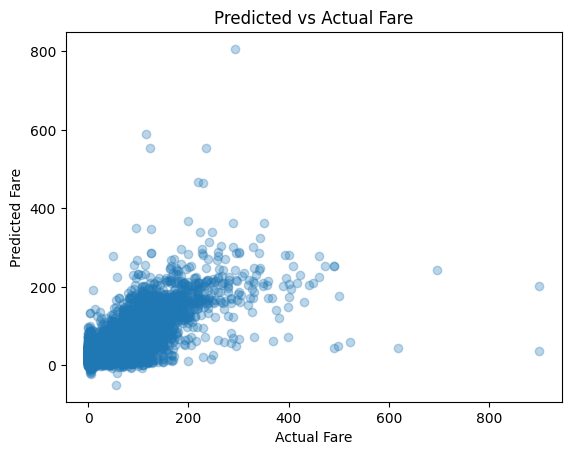

In [23]:
# plot predicted vs. actual
import matplotlib.pyplot as plt

pdf = test_predictions.select("fare_amount", "prediction").toPandas()

plt.scatter(pdf["fare_amount"], pdf["prediction"], alpha=0.3)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Predicted vs Actual Fare")

img_path = "fare_prediction.png"
plt.savefig(img_path)


## Part 7: Write results to S3

In [28]:
import boto3

session = boto3.Session()
s3 = session.client("s3")

In [29]:
bucket_name = "nky8459-de300"
s3_prefix = "nyc-taxi-assignment"

# upload tables
train_predictions.write.mode("overwrite").parquet("train_predictions")
test_predictions.write.mode("overwrite").parquet("test_predictions")

In [30]:
import os

def upload_directory_to_s3(local_dir, bucket, s3_prefix):
    for root, dirs, files in os.walk(local_dir):
        for file in files:
            local_path = os.path.join(root, file)

            # Construct S3 key (preserve folder structure)
            relative_path = os.path.relpath(local_path, local_dir)
            s3_key = f"{s3_prefix}/{local_dir}/{relative_path}"

            s3.upload_file(local_path, bucket, s3_key)

In [31]:
upload_directory_to_s3("train_predictions", bucket_name, s3_prefix)
upload_directory_to_s3("test_predictions", bucket_name, s3_prefix)

In [32]:
# upload plot
s3.upload_file(img_path, bucket_name, f"{s3_prefix}/fare_predictions.png")